# _ Modeling Draft 1 _

**Objectif :** Tester plusieurs algorithmes de Machine Learning pour prédire le PCOS et comparer leurs performances.


---
## Importation des librairies

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier



sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

---
## Chargement des données

In [ ]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(f'X_train shape : {X_train.shape}')

print(f'X_test shape  : {X_test.shape}')

X_train shape : (1600, 20)
X_test shape  : (400, 20)


---
##  Fonction d'évaluation

In [ ]:
results = []

def evaluate_model(model, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan

    # Cross Validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_f1 = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1')

    results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'ROC-AUC': round(auc, 4),
        'CV_F1_mean': round(cv_f1.mean(), 4),
        'CV_F1_std': round(cv_f1.std(), 4)
    })

    print(f' {name:25}  ==  F1: {f1:.4f} | AUC: {auc:.4f} | CV_F1: {cv_f1.mean():.4f}')

---
##  Entraînement des modèles

In [10]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=400, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=400, learning_rate=0.08, max_depth=6, random_state=42, eval_metric='logloss'),
    "LightGBM": LGBMClassifier(n_estimators=400, learning_rate=0.08, max_depth=6, random_state=42, verbose=-1),
    "SVM RBF": SVC(probability=True, kernel='rbf', random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=7)
}

for name, clf in models.items():
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', clf)
    ])
    evaluate_model(pipeline, name)

✅ Logistic Regression       → F1: 0.8745 | AUC: 0.9621 | CV_F1: 0.8285
✅ Random Forest             → F1: 0.9959 | AUC: 0.9999 | CV_F1: 0.9821
✅ XGBoost                   → F1: 0.9878 | AUC: 0.9999 | CV_F1: 0.9832


c:\Users\yasmi\anaconda3\envs\pcos_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\yasmi\anaconda3\envs\pcos_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\yasmi\anaconda3\envs\pcos_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\yasmi\anaconda3\envs\pcos_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\yasmi\anaconda3\envs\pcos_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted w

✅ LightGBM                  → F1: 0.9918 | AUC: 0.9999 | CV_F1: 0.9787
✅ SVM RBF                   → F1: 0.9712 | AUC: 0.9984 | CV_F1: 0.9423
✅ KNN                       → F1: 0.8803 | AUC: 0.9744 | CV_F1: 0.8491


---
##  Résultats Comparatifs

In [11]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='F1-Score', ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,CV_F1_mean,CV_F1_std
0,Random Forest,0.9975,1.0000,0.9918,0.9959,0.9999,0.9821,0.0145
1,LightGBM,0.9950,0.9918,0.9918,0.9918,0.9999,0.9787,0.0180
2,XGBoost,0.9925,0.9837,0.9918,0.9878,0.9999,0.9832,0.0124
3,SVM RBF,0.9825,0.9752,0.9672,0.9712,0.9984,0.9423,0.0156
4,KNN,0.9300,0.9196,0.8443,0.8803,0.9744,0.8491,0.0227
5,Logistic Regression,0.9275,0.9266,0.8279,0.8745,0.9621,0.8285,0.0229


C:\Users\yasmi\AppData\Local\Temp\ipykernel_20136\2062065928.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='F1-Score', y='Model', palette='viridis')


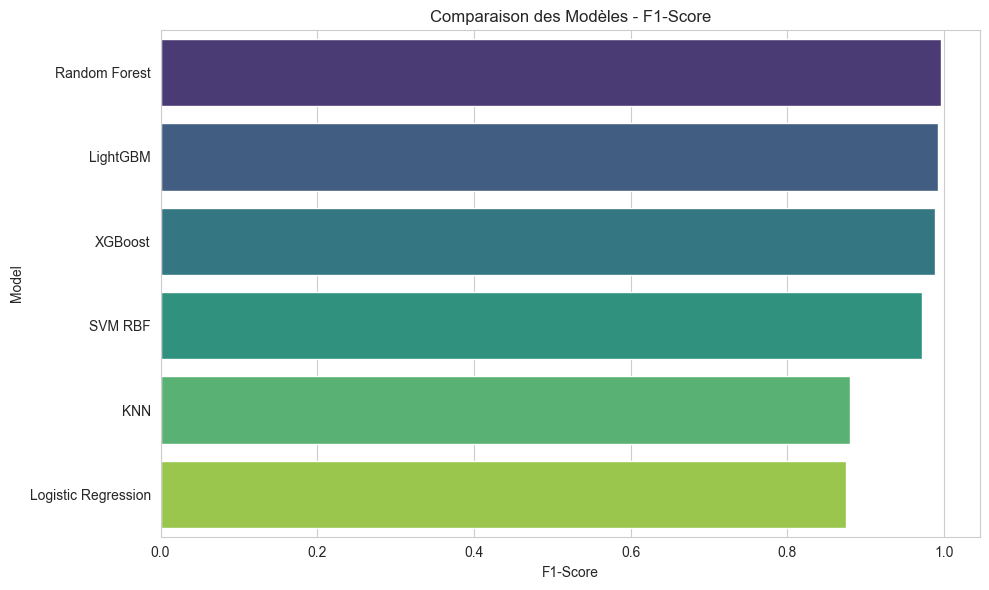

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='F1-Score', y='Model', palette='viridis')
plt.title('Comparaison des Modèles - F1-Score')
plt.xlabel('F1-Score')
plt.tight_layout()
plt.show()

---
## Analyse du Meilleur Modèle

🚀 Meilleur modèle actuel : Random Forest

CLASSIFICATION REPORT - MEILLEUR MODÈLE
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       278
           1       1.00      0.99      1.00       122

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



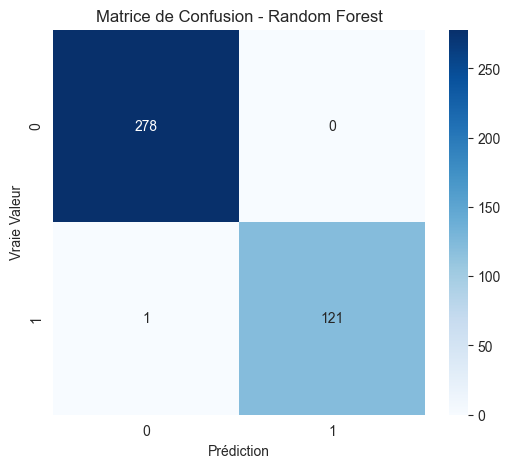

In [ ]:
best_model_name = results_df.iloc[0]['Model']
print(f" Meilleur modèle actuel : {best_model_name}")

best_clf = models[best_model_name]
best_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', best_clf)
])
best_pipeline.fit(X_train, y_train)
y_pred = best_pipeline.predict(X_test)

print("\n" + "_"*60)
print("CLASSIFICATION REPORT - MEILLEUR MODÈLE")
print("_"*60)
print(classification_report(y_test, y_pred))

plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title(f'Matrice de Confusion - {best_model_name}')
plt.ylabel('Vraie Valeur')
plt.xlabel('Prédiction')
plt.show()

---
##  Feature Importance

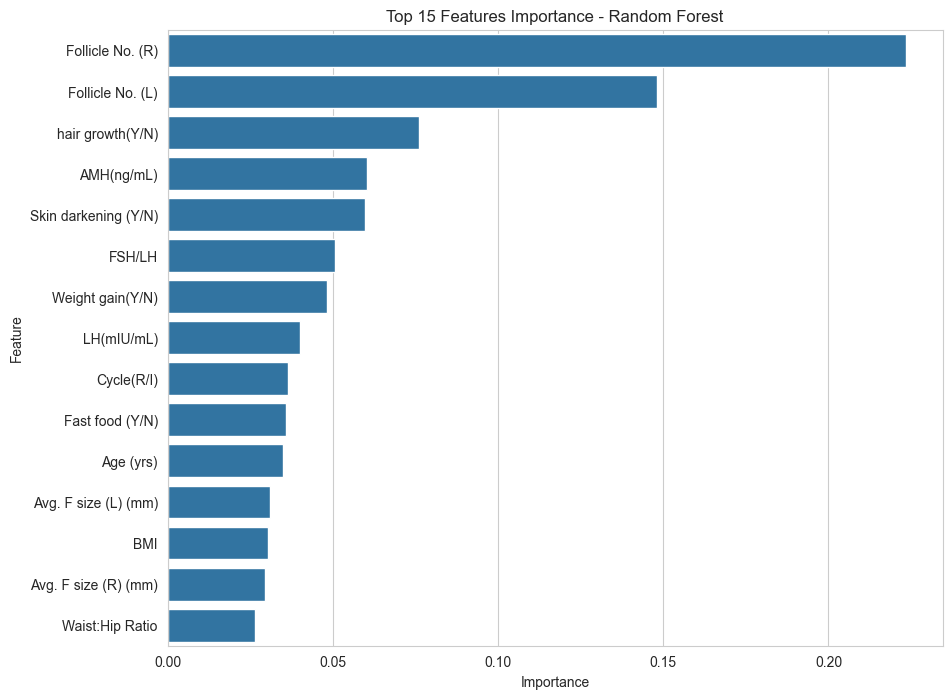

In [14]:
if 'XGBoost' in best_model_name or 'Random Forest' in best_model_name or 'LightGBM' in best_model_name:
    clf = best_pipeline.named_steps['classifier']
    feat_imp = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': clf.feature_importances_
    }).sort_values('Importance', ascending=False)

    plt.figure(figsize=(10, 8))
    sns.barplot(data=feat_imp.head(15), x='Importance', y='Feature')
    plt.title(f'Top 15 Features Importance - {best_model_name}')
    plt.show()